# Comparación: Red Densa vs Red Convolucional

### Daniel Velasco González

En este notebook la **red densa** recibe la entrada ya aplanada (vector), no una matriz.
El aplanado se hace en el preprocesamiento, antes de alimentar la red.

In [1]:
import keras
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test: (10000, 32, 32, 3) y_test: (10000, 1)


/Users/daniv/dev/USA/neural-networks/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


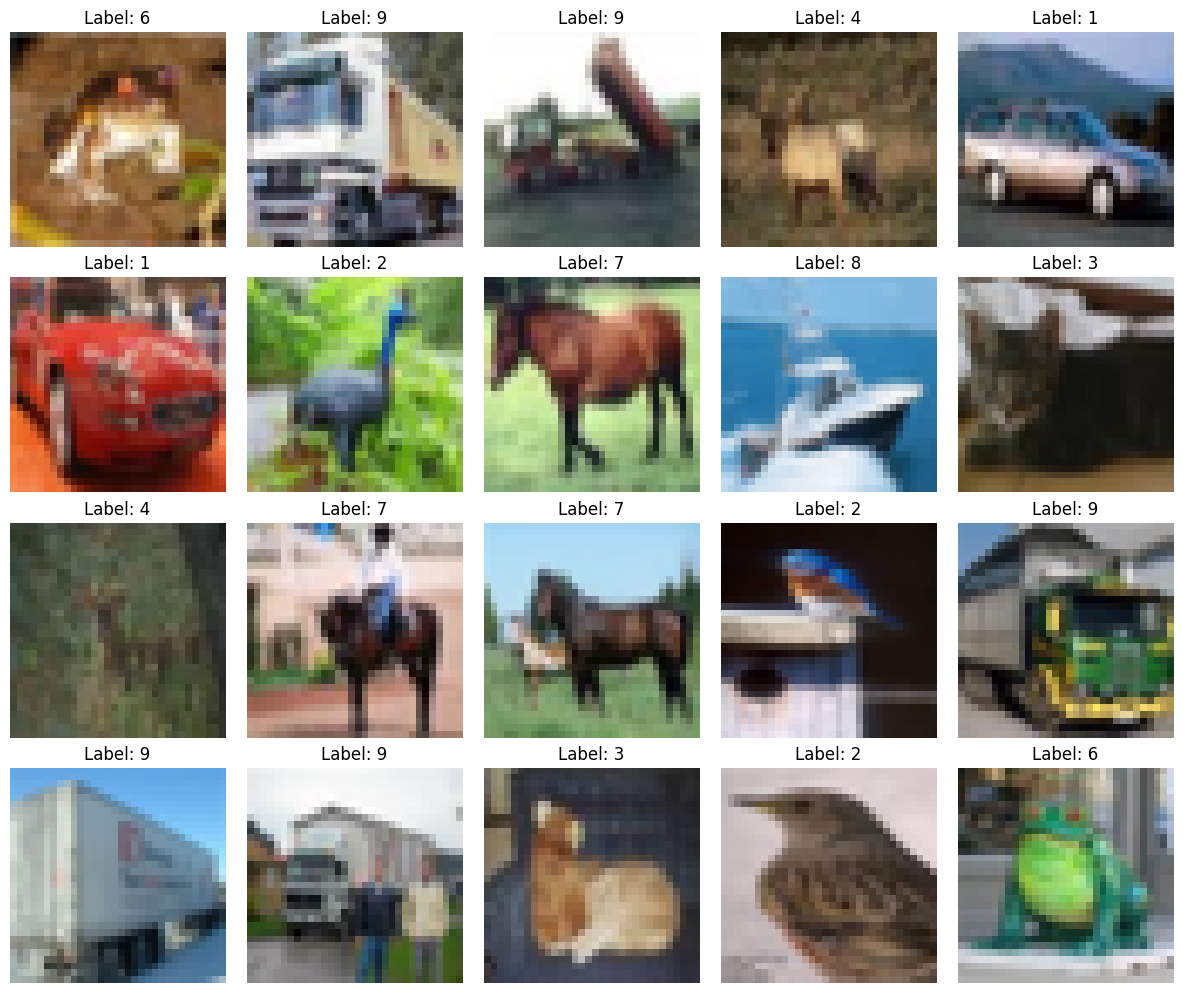

In [3]:
plt.figure(figsize=(12, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Label: {y_train[i][0]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocesamiento

- **Red densa**: normalizar + aplanar (32×32×3 → 3072) → vector por muestra
- **Red convolucional**: solo normalizar, mantiene forma (32, 32, 3)

In [4]:
# Normalización a [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Para red densa: aplanar antes de entrar a la red (no Flatten dentro del modelo)
n_train, h, w, c = x_train_norm.shape
n_test = x_test_norm.shape[0]
x_train_flat = x_train_norm.reshape(n_train, h * w * c)
x_test_flat = x_test_norm.reshape(n_test, h * w * c)

print("Red densa (entrada vector):", x_train_flat.shape)
print("Red convolucional (entrada matriz):", x_train_norm.shape)

Red densa (entrada vector): (50000, 3072)
Red convolucional (entrada matriz): (50000, 32, 32, 3)


### Modelo 1: Red solo densa

Entrada: vector de 3072 (ya aplanado). No usa Flatten ni matrices.

In [5]:
modelo_densa = keras.models.Sequential([
    keras.layers.Input(shape=(3072,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
modelo_densa.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
modelo_densa.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,038 (3.02 MB)

 Trainable params: 792,038 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

### Modelo 2: Red convolucional + densa

- Conv2D 32 filtros 3×3
- Conv2D 16 filtros 3×3
- Flatten
- Dense 20
- Dense salida

In [6]:
modelo_conv = keras.models.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.Conv2D(16, (3, 3), activation="relu"),
    keras.layers.Flatten(),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
modelo_conv.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
modelo_conv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │       250,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,630 (1002.46 KB)

 Trainable params: 256,630 (1002.46 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [7]:
print("=" * 50)
print("Entrenando modelo DENSE (entrada vector)...")
print("=" * 50)

history_densa = modelo_densa.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo DENSE (entrada vector)...
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0977 - loss: 2.3032 - val_accuracy: 0.0952 - val_loss: 2.3029
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0988 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3029
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0968 - loss: 2.3028 - val_accuracy: 0.0980 - val_loss: 2.3029
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0982 - loss: 2.3027 - val_accuracy: 0.0977 - val_loss: 2.3029
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0992 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3029
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1008 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3028
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.0997 - val_loss: 2.3028
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1

In [8]:
print("=" * 50)
print("Entrenando modelo CONVOLUCIONAL...")
print("=" * 50)
history_conv = modelo_conv.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo CONVOLUCIONAL...
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3276 - loss: 1.8258 - val_accuracy: 0.4088 - val_loss: 1.6338
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4566 - loss: 1.4987 - val_accuracy: 0.4833 - val_loss: 1.4295
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4993 - loss: 1.3694 - val_accuracy: 0.5038 - val_loss: 1.3729
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5364 - loss: 1.2731 - val_accuracy: 0.5413 - val_loss: 1.2894
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5825 - loss: 1.1654 - val_accuracy: 0.5670 - val_loss: 1.2456
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6246 - loss: 1.0646 - val_accuracy: 0.5834 - val_loss: 1.1934
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6510 - loss: 0.9875 - val_accuracy: 0.5878 - val_loss: 1.1968
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step -

### Evaluación en test

In [9]:
eval_densa = modelo_densa.evaluate(x_test_flat, y_test)
eval_conv = modelo_conv.evaluate(x_test_norm, y_test)

print("\n--- Comparación en test ---")
print(f"Red densa (vector):     loss={eval_densa[0]:.4f}, accuracy={eval_densa[1]:.4f}")
print(f"Red convolucional:     loss={eval_conv[0]:.4f}, accuracy={eval_conv[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.1000 - loss: 2.3026
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5931 - loss: 1.2154

--- Comparación en test ---
Red densa (vector):     loss=2.3026, accuracy=0.1000
Red convolucional:     loss=1.2154, accuracy=0.5931


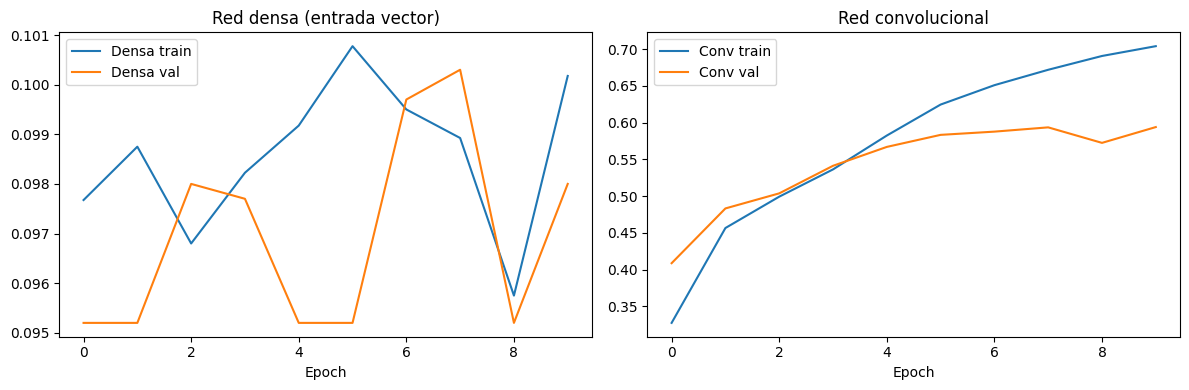

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_densa.history["accuracy"], label="Densa train")
axes[0].plot(history_densa.history["val_accuracy"], label="Densa val")
axes[0].set_title("Red densa (entrada vector)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_conv.history["accuracy"], label="Conv train")
axes[1].plot(history_conv.history["val_accuracy"], label="Conv val")
axes[1].set_title("Red convolucional")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()